# 04. Model Evaluation

학습 완료된 MobileNetV2 모델의 Test set 평가
- Overall accuracy, per-class precision/recall/F1
- Confusion matrix 시각화
- 오류 샘플 분석

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE = 224
BATCH_SIZE = 32
DATA_DIR = '/Users/parkyoungbin/Desktop/ml2/model/data'
SAVE_DIR = '/Users/parkyoungbin/Desktop/ml2/model/saved_model'

In [2]:
# 데이터 + 모델 로드
test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
labels_sorted = sorted(test_df['label'].unique())
label2idx = {l: i for i, l in enumerate(labels_sorted)}
NUM_CLASSES = len(labels_sorted)
test_df['label_idx'] = test_df['label'].map(label2idx)

model = tf.keras.models.load_model(os.path.join(SAVE_DIR, 'fashion_final.keras'))
print(f'Model loaded. Test samples: {len(test_df)}')
print(f'Classes: {labels_sorted}')

Model loaded. Test samples: 3201
Classes: ['Boots', 'Dress', 'Hoodie', 'Jacket', 'Jeans', 'Pants', 'Shirt', 'Sneakers', 'T-shirt']


In [3]:
# tf.data 파이프라인
@tf.autograph.experimental.do_not_convert
def load_and_preprocess(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)
    return img, label

paths = test_df['image_path'].values
labels_onehot = tf.one_hot(test_df['label_idx'].values, NUM_CLASSES)
test_ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
test_ds = test_ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 1. Overall Test Performance

In [4]:
loss, acc = model.evaluate(test_ds, verbose=0)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')
print(f'Test Loss: {loss:.4f}')

y_pred_probs = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_df['label_idx'].values

Test Accuracy: 0.9075 (90.8%)
Test Loss: 0.2456


## 2. Per-Class Classification Report

In [5]:
report = classification_report(y_true, y_pred, target_names=labels_sorted, digits=3)
print(report)

              precision    recall  f1-score   support

       Boots      0.775     0.778     0.776       270
       Dress      0.770     0.918     0.838       146
      Hoodie      0.663     0.736     0.698        91
      Jacket      0.871     0.810     0.839       100
       Jeans      0.874     0.922     0.897        90
       Pants      0.942     0.931     0.937       246
       Shirt      0.903     0.968     0.934       412
    Sneakers      0.922     0.922     0.922       778
     T-shirt      0.981     0.922     0.951      1068

    accuracy                          0.908      3201
   macro avg      0.856     0.879     0.866      3201
weighted avg      0.911     0.908     0.908      3201



## 3. Confusion Matrix

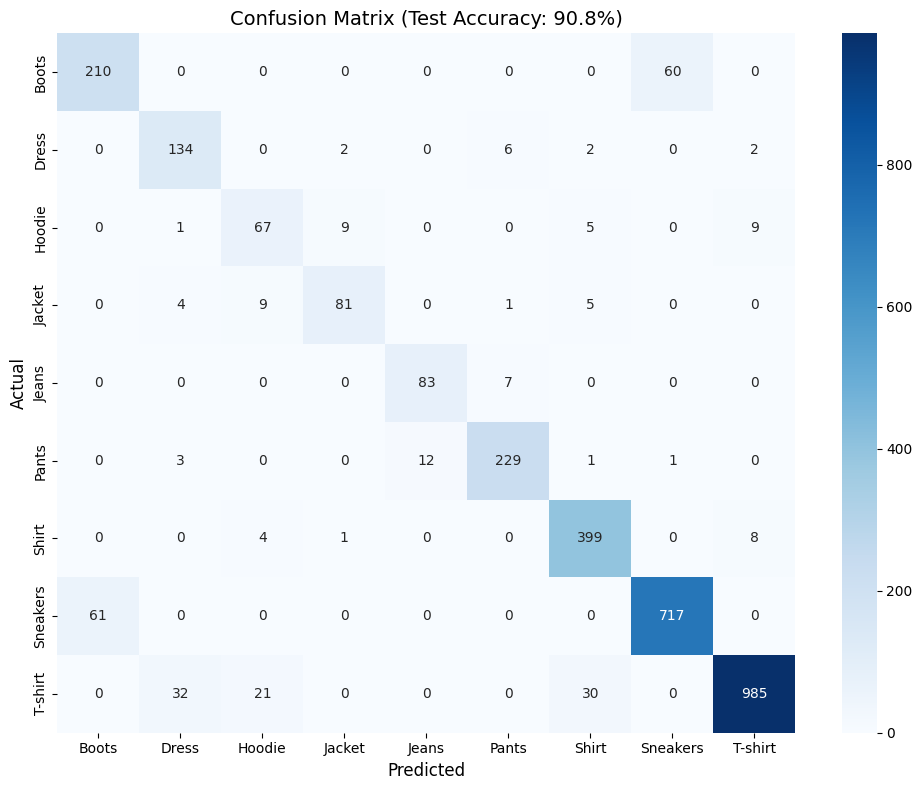

In [6]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Confusion Matrix (Test Accuracy: {acc:.1%})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 4. 주요 혼동 분석

In [7]:
# 가장 많이 혼동하는 쌍 찾기
errors = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm[i][j] > 0:
            errors.append((labels_sorted[i], labels_sorted[j], cm[i][j]))

errors.sort(key=lambda x: x[2], reverse=True)
print('Top 10 Confusion Pairs:')
print(f'{"Actual":<12} {"Predicted":<12} {"Count":<6}')
print('-' * 32)
for actual, predicted, count in errors[:10]:
    print(f'{actual:<12} {predicted:<12} {count:<6}')

Top 10 Confusion Pairs:
Actual       Predicted    Count 
--------------------------------
Sneakers     Boots        61    
Boots        Sneakers     60    
T-shirt      Dress        32    
T-shirt      Shirt        30    
T-shirt      Hoodie       21    
Pants        Jeans        12    
Hoodie       Jacket       9     
Hoodie       T-shirt      9     
Jacket       Hoodie       9     
Shirt        T-shirt      8     


## 5. 오류 샘플 시각화

전체 오류 수: 296 / 3201 (9.2%)


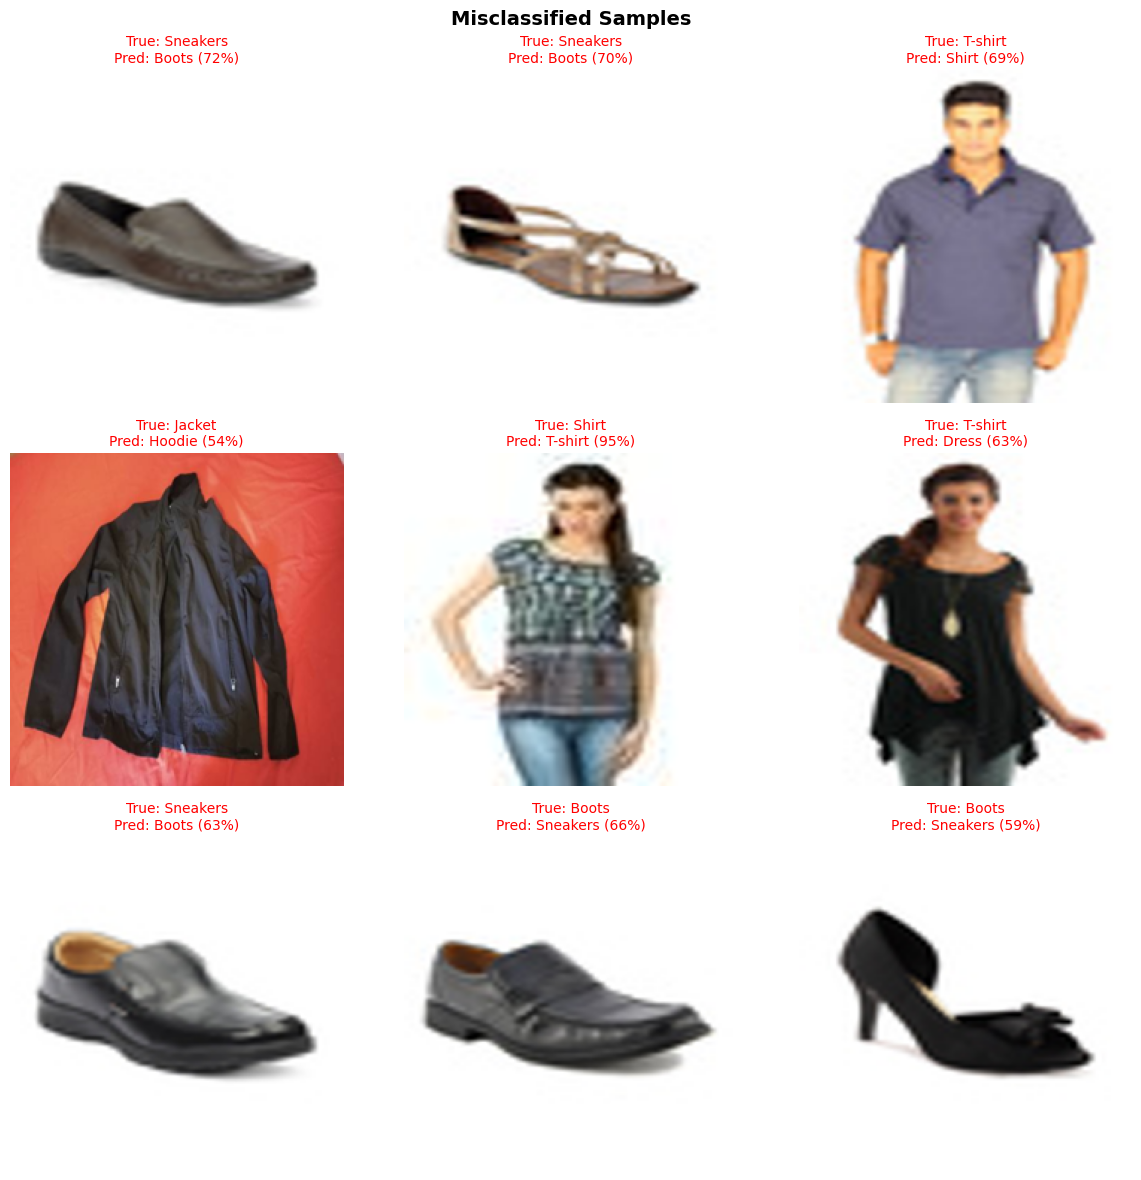

In [8]:
from PIL import Image

# 틀린 샘플 찾기
wrong_mask = y_pred != y_true
wrong_indices = np.where(wrong_mask)[0]
print(f'전체 오류 수: {len(wrong_indices)} / {len(y_true)} ({len(wrong_indices)/len(y_true)*100:.1f}%)')

# 랜덤 오류 샘플 9개 시각화
np.random.seed(42)
sample_indices = np.random.choice(wrong_indices, min(9, len(wrong_indices)), replace=False)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for idx, ax in zip(sample_indices, axes.flat):
    row = test_df.iloc[idx]
    img = Image.open(row['image_path']).resize((224, 224))
    ax.imshow(img)
    true_label = labels_sorted[y_true[idx]]
    pred_label = labels_sorted[y_pred[idx]]
    conf = y_pred_probs[idx][y_pred[idx]] * 100
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({conf:.0f}%)',
                 color='red', fontsize=10)
    ax.axis('off')

plt.suptitle('Misclassified Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()